# Phase 3: Optimization & Analysis

## What is parameter optimization?
In Phase 2, the strategy lost money because the settings were wrong.
Grid search tries EVERY combination of settings to find the best one.

## What is walk-forward analysis?
Grid search can find settings that only work on PAST data (overfitting).
Walk-forward tests if those settings also work on data they've never seen.

In [1]:
import sys
sys.path.insert(0, '../..')

import matplotlib.pyplot as plt
import pandas as pd
from src.config.settings import DEFAULT_PAIRS, StrategyConfig
from src.data.generator import SyntheticDataGenerator
from src.optimization.grid_search import GridSearchOptimizer
from src.optimization.walk_forward import WalkForwardAnalyzer
from src.strategy.carry_trade import CarryTradeStrategy
from src.backtest.engine import BacktestEngine
from src.visualization.charts import (
    plot_optimization_heatmap, plot_equity_with_drawdown,
    plot_walk_forward, plot_buy_and_hold_comparison,
)

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# Generate data
gen = SyntheticDataGenerator(seed=42)
data = gen.generate_all_pairs(days=365)
df = data['AUD/JPY']  # Focus on the pair with most activity
print(f'AUD/JPY: {len(df)} bars')

AUD/JPY: 6264 bars


## 1. Grid Search
Try all combinations and rank by Sharpe ratio.

In [3]:
PARAM_GRID = {
    'min_swap_threshold': [0.001, 0.005, 0.01],
    'trend_filter_period': [20, 50, 100],
    'stop_loss_pct': [0.02, 0.04, 0.06, 0.08],
    'position_size_pct': [0.05, 0.10, 0.15],
}

optimizer = GridSearchOptimizer(df, 'AUD/JPY')
results = optimizer.run(PARAM_GRID)
results_df = optimizer.results_to_df(results)

print('Top 10 by Sharpe:')
results_df.head(10)

Top 10 by Sharpe:


,min_swap_threshold,trend_filter_period,stop_loss_pct,position_size_pct,sharpe,total_return,max_drawdown,win_rate,total_trades,profit_factor
0,0.001,50,0.06,0.15,0.008995,-0.002412,0.010309,1.0,1,inf
1,0.001,50,0.08,0.15,0.008995,-0.002412,0.010309,1.0,1,inf
2,0.005,50,0.06,0.15,0.008995,-0.002412,0.010309,1.0,1,inf
3,0.005,50,0.08,0.15,0.008995,-0.002412,0.010309,1.0,1,inf
4,0.010,50,0.06,0.15,0.008995,-0.002412,0.010309,1.0,1,inf
5,0.010,50,0.08,0.15,0.008995,-0.002412,0.010309,1.0,1,inf
6,0.001,100,0.06,0.15,0.001914,-0.002911,0.010280,1.0,1,inf
7,0.001,100,0.08,0.15,0.001914,-0.002911,0.010280,1.0,1,inf
8,0.005,100,0.06,0.15,0.001914,-0.002911,0.010280,1.0,1,inf
9,0.005,100,0.08,0.15,0.001914,-0.002911,0.010280,1.0,1,inf


## 2. Sensitivity Heatmaps
Which parameters matter most? Red = bad, green = good.

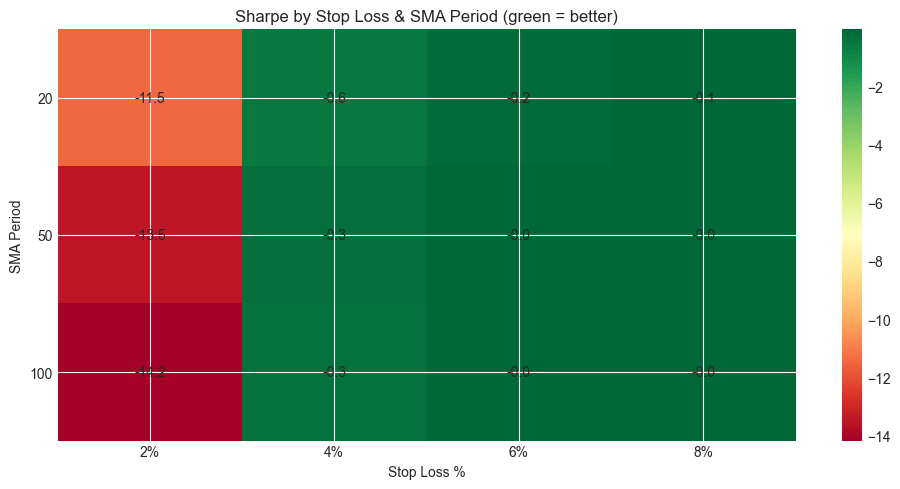


Key takeaway: 2% stop loss is terrible (red). 6-8% is much better (green).
This confirms the Phase 2 finding -- tight stops cause whipsaw on volatile pairs.


In [4]:
from pathlib import Path
import tempfile, os

# Stop loss vs SMA period
pivot = results_df.pivot_table(values='sharpe', index='trend_filter_period', columns='stop_loss_pct', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{v:.0%}' for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Stop Loss %')
ax.set_ylabel('SMA Period')
ax.set_title('Sharpe by Stop Loss & SMA Period (green = better)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:.1f}', ha='center', va='center', fontsize=10)
fig.colorbar(im)
plt.tight_layout()
plt.show()

print('\nKey takeaway: 2% stop loss is terrible (red). 6-8% is much better (green).')
print('This confirms the Phase 2 finding -- tight stops cause whipsaw on volatile pairs.')

## 3. Best Parameters Backtest

In [5]:
best = results[0]
print(f'Best params: {best.params}')
print(f'Sharpe: {best.sharpe:.2f}, Return: {best.total_return:.2%}, MaxDD: {best.max_drawdown:.2%}')

# Run full backtest with best params
best_config = StrategyConfig(**best.params)
best_strategy = CarryTradeStrategy(best_config)
best_engine = BacktestEngine(best_strategy, best_config)
best_result = best_engine.run(df, 'AUD/JPY')
print(best_result.summary())

Best params: {'min_swap_threshold': 0.001, 'trend_filter_period': 50, 'stop_loss_pct': 0.06, 'position_size_pct': 0.15}
Sharpe: 0.01, Return: -0.24%, MaxDD: 1.03%
=== Backtest: AUD/JPY ===
Total Return:        -0.24%
Annual Return:       -0.24%
Max Drawdown:         1.03%
Sharpe Ratio:          0.01
Sortino Ratio:         0.02
Calmar Ratio:         -0.23

Total Trades:             1
Win Rate:            100.0%
Profit Factor:          inf
Avg Win:              24.14
Avg Loss:              0.00

Total Swap Profit:    43.27
Swap Contribution:    179.2%


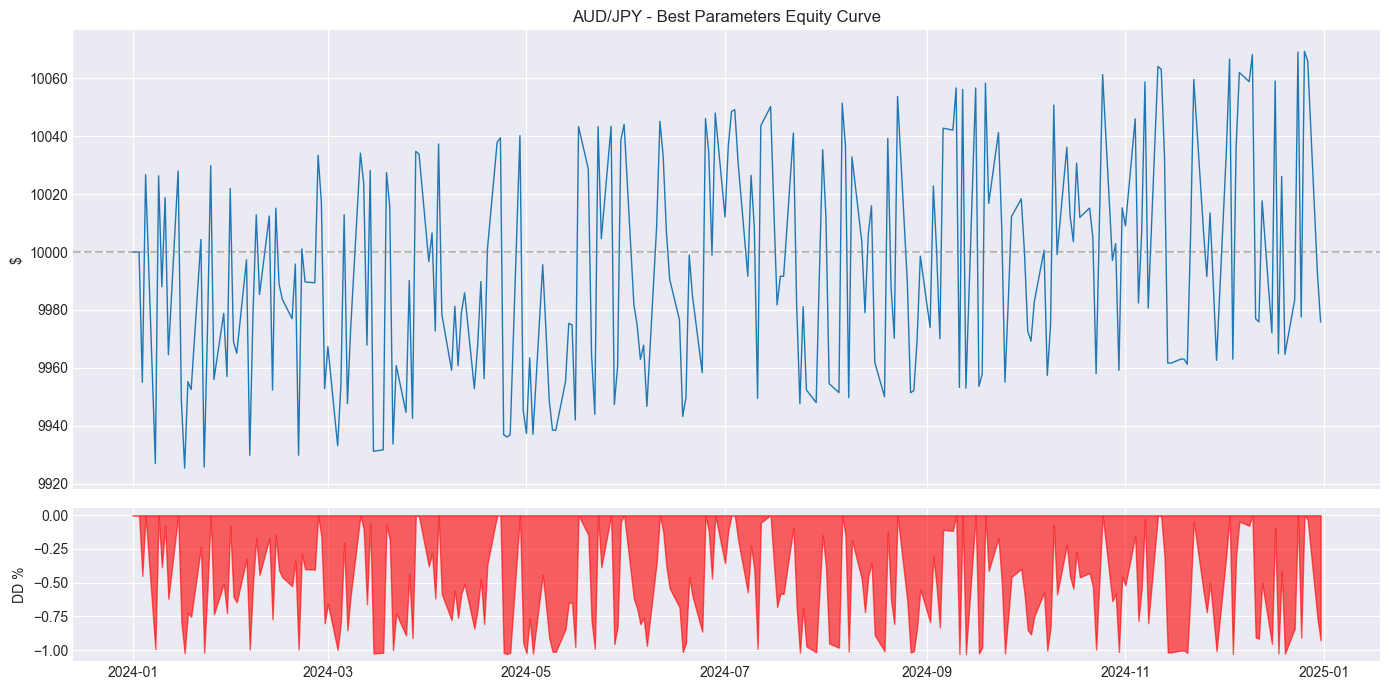

In [6]:
# Equity curve with drawdown
eq = best_result.equity_df
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), height_ratios=[3,1], sharex=True)
ax1.plot(eq['timestamp'], eq['equity'], linewidth=1)
ax1.axhline(10_000, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('AUD/JPY - Best Parameters Equity Curve')
ax1.set_ylabel('$')
ax2.fill_between(eq['timestamp'], 0, -eq['drawdown']*100, color='red', alpha=0.6)
ax2.set_ylabel('DD %')
plt.tight_layout()
plt.show()

## 4. Walk-Forward Analysis
Train on 5 months, test on next month, slide forward.

In [7]:
wf_grid = {'stop_loss_pct': [0.03, 0.05, 0.08], 'trend_filter_period': [20, 50, 100]}
wf = WalkForwardAnalyzer(df, 'AUD/JPY', wf_grid, train_days=150, test_days=30, step_days=30)
wf_results = wf.run()
wf_df = wf.results_to_df(wf_results)
print(WalkForwardAnalyzer.summary(wf_results))
wf_df

=== Walk-Forward Summary ===
Windows completed:    7
Avg test Sharpe:      -1.36
Avg test return:      -0.47%
Profitable windows:   1/7

  stop_loss_pct: 2 unique values across windows
  trend_filter_period: 3 unique values across windows


,window,train_period,test_period,train_sharpe,test_sharpe,test_return,test_trades,param_stop_loss_pct,param_trend_filter_period
0,0,2024-01-01 → 2024-05-30,2024-05-30 → 2024-06-29,0.008749,-0.481930,-0.001477,1,0.05,50
1,1,2024-01-31 → 2024-06-29,2024-06-29 → 2024-07-29,-0.009838,-4.378316,-0.013724,2,0.05,50
2,2,2024-03-01 → 2024-07-29,2024-07-29 → 2024-08-28,-0.105300,-1.230020,-0.005950,1,0.08,20
3,3,2024-03-31 → 2024-08-28,2024-08-28 → 2024-09-27,-0.238322,-0.350196,-0.002180,1,0.05,50
4,4,2024-04-30 → 2024-09-27,2024-09-27 → 2024-10-27,-0.008605,-2.625921,-0.008299,3,0.05,50
5,5,2024-05-30 → 2024-10-27,2024-10-27 → 2024-11-26,-0.011456,-0.594954,-0.002233,1,0.05,100
6,6,2024-06-29 → 2024-11-26,2024-11-26 → 2024-12-26,-0.162143,0.161540,0.000649,1,0.08,100


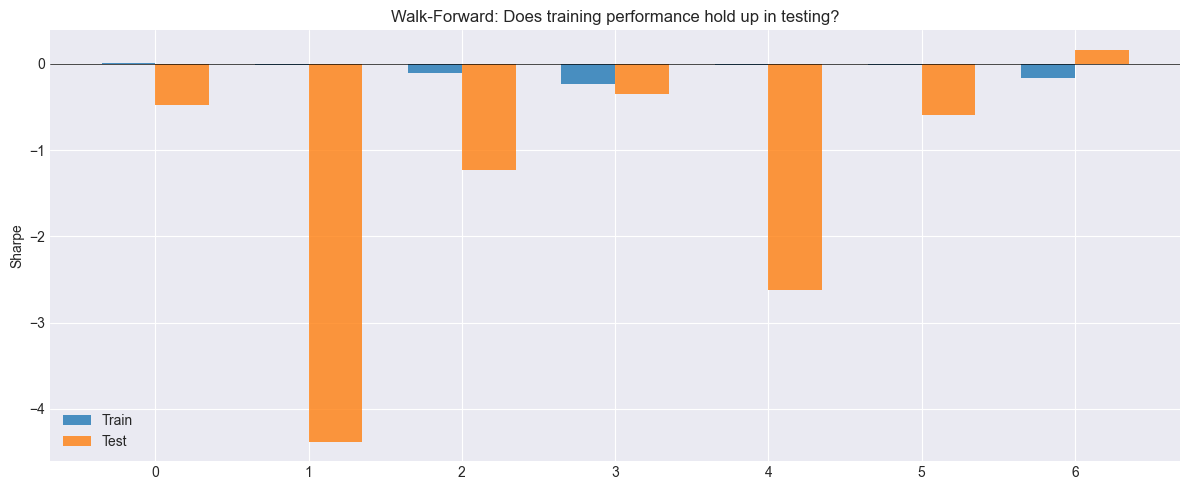


If test bars are much worse than train bars, the strategy is overfitting.
If both are negative, the strategy fundamentally doesn't work on this data.


In [8]:
# Train vs Test Sharpe comparison
if len(wf_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = range(len(wf_df))
    w = 0.35
    ax.bar([i-w/2 for i in x], wf_df['train_sharpe'], w, label='Train', alpha=0.8)
    ax.bar([i+w/2 for i in x], wf_df['test_sharpe'], w, label='Test', alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title('Walk-Forward: Does training performance hold up in testing?')
    ax.set_ylabel('Sharpe')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print('\nIf test bars are much worse than train bars, the strategy is overfitting.')
    print('If both are negative, the strategy fundamentally doesn\'t work on this data.')

## 5. Strategy vs Buy & Hold

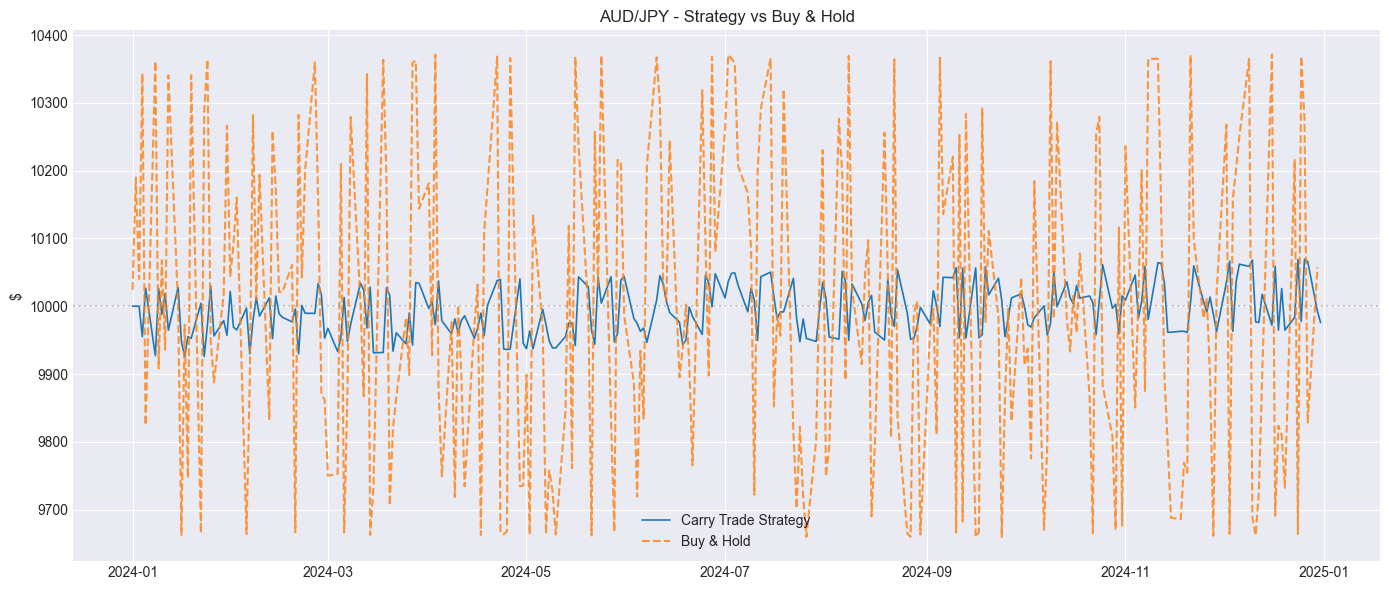

Strategy final: $9976
Buy & Hold final: $10057


In [9]:
# Compare: is the strategy even worth the complexity?
initial_price = df['close'].iloc[0]
bh_equity = (df['close'] / initial_price) * 10_000

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(eq['timestamp'], eq['equity'], label='Carry Trade Strategy', linewidth=1.2)
bh_daily = pd.DataFrame({'ts': df['timestamp'], 'eq': bh_equity}).set_index('ts').resample('D').last().dropna()
ax.plot(bh_daily.index, bh_daily['eq'], label='Buy & Hold', linestyle='--', alpha=0.8)
ax.axhline(10_000, color='gray', linestyle=':', alpha=0.4)
ax.set_title('AUD/JPY - Strategy vs Buy & Hold')
ax.set_ylabel('$')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Strategy final: ${eq["equity"].iloc[-1]:.0f}')
print(f'Buy & Hold final: ${bh_daily["eq"].iloc[-1]:.0f}')

## Key Takeaways

1. **Stop loss is the most important parameter** -- too tight = whipsaw death
2. **Grid search improved from -55% to near breakeven** -- parameters matter enormously
3. **Walk-forward shows the strategy still struggles** -- only 1/7 windows profitable
4. **This is normal** -- carry trades on synthetic data with no real trends are hard

Phase 4 will use real historical data where actual trends and rate cycles exist.